# Feature Selection for Machine Learning by Black-Box Optimization

## Introduction

The input data fed to a machine learning model consists of many features (the individual attributes of each data point). Not all of them are useful for prediction, however, which is why “feature selection” — keeping only the features that matter and discarding the rest — is common practice.

Selecting only the features that contribute to prediction yields a lightweight model that achieves high prediction accuracy while keeping training and inference computational costs low.

In this tutorial, we perform feature selection on a handwritten digit image classification problem (MNIST). Each image is represented by 28x28 pixels, or 784 pixels in total (features). Our task is to decide whether to use each feature and to find the combination of features that yields the best classification model.

We want classification accuracy to be as high as possible while using as few features as possible. These goals pull in opposite directions: using fewer features tends to lower classification accuracy, while prioritizing accuracy tends to require more features. We therefore need a solution that balances the two. Optimization that handles multiple objectives simultaneously is called multi-objective optimization.

The search itself is also demanding. There are far too many combinations of 784 “use” / “do not use” decisions to try exhaustively, and evaluating even a single combination requires training a classification model and measuring its performance, which is time-consuming.

For this reason, this tutorial uses [Amplify-BBOpt](https://amplify.fixstars.com/en/docs/amplify-bbopt/v1/), a black-box optimization library well suited to problems of this kind. Amplify-BBOpt is a Python library that efficiently solves black-box optimization problems by leveraging quantum-inspired technology, and it excels at high-dimensional searches and at problems whose evaluations are expensive.

For the basics of black-box optimization with machine learning and quantum annealing/Ising machines, see [Black-Box Optimization with Quantum Annealing and Ising Machines](https://amplify.fixstars.com/en/demo/fmqa_0_algebra), and for other examples of black-box optimization methods, see [here](https://amplify.fixstars.com/en/demo#blackbox).

## Table of contents

- 1\. [MNIST and Feature Selection](#sec-1)
  - 1.1\. [What is MNIST?](#sec-1_1)
  - 1.2\. [Feature Selection Flow](#sec-1_2)
  - 1.3\. [Two Objectives and the Pareto Front](#sec-1_3)
  - 1.4\. [Loading and Preprocessing the Data](#sec-1_4)
  - 1.5\. [Functions for Applying the Mask, Training, and Evaluation](#sec-1_5)
  - 1.6\. [Model Accuracy Using All Features](#sec-1_6)
- 2\. [Multi-Objective Black-Box Optimization with MultiOptimizer](#sec-2)
  - 2.1\. [Black-Box Function](#sec-2_1)
  - 2.2\. [Generating Initial Training Data](#sec-2_2)
  - 2.3\. [Solver Configuration](#sec-2_3)
  - 2.4\. [Instantiating MultiOptimizer](#sec-2_4)
  - 2.5\. [Designing the Weight Schedule](#sec-2_5)
  - 2.6\. [Running the Optimization Cycle](#sec-2_6)
- 3\. [Visualizing the Optimization History](#sec-3)
  - 3.1\. [Evolution of Objective Function Values for the Explored Solutions](#sec-3_1)
  - 3.2\. [Pareto Front](#sec-3_2)
  - 3.3\. [Summary](#sec-3_3)

<a id="sec-1"></a>

## 1\. MNIST and Feature Selection

<a id="sec-1_1"></a>

### 1.1\. What is MNIST?

The Modified National Institute of Standards and Technology (MNIST) dataset is a database of handwritten digit images widely used to train and test image processing models. It consists of 28x28 pixel images of handwritten digits, each paired with the digit it represents as a label. Below are a few representative samples from the training data (the number in brackets above each image is the label assigned to that image).



The machine learning model in this sample program takes a handwritten digit image as input and predicts the digit it represents — in other words, it classifies handwritten images.

<a id="sec-1_2"></a>

### 1.2\. Feature Selection Flow

The figure below shows the feature selection flow used in this tutorial. The raw data for this machine learning model is the brightness values of the 28x28 pixels of a handwritten image, i.e., $N_f = 28 \times 28 = 784$ features. Feature selection picks an appropriate subset of $N_f'\ (\leq N_f)$ features out of the $N_f$ available, and only those $N_f'$ features are passed to the model as input.

As shown in the figure, the choice of which $N_f'$ features to keep is represented by a mask. The mask is an array of $N_f$ elements with values (`True` or `False`) indicating whether the corresponding feature is selected (`True` means selected).



<a id="sec-1_3"></a>

### 1.3\. Two Objectives and the Pareto Front

This sample pursues two objectives at once: maximizing classification accuracy — equivalently, minimizing the error rate — and minimizing the number of features used. The two are in a trade-off relationship. Using fewer features tends to raise the error rate, since the model has less information to work with, while lowering the error rate tends to require more features.

When objectives trade off against each other like this, there is usually no single optimal solution that minimizes all of them at once. Instead, the answer is a set of solutions in which improving one objective necessarily worsens the other, so that no solution is strictly better than another. Such solutions are called **Pareto-optimal solutions**, and plotting them in the objective space traces out the **Pareto front**.



The goal of this sample is to find the Pareto front with Amplify-BBOpt. Once we have it, we can weigh the trade-off between error rate and number of features and select the solution that best fits our practical requirements (the Pareto front is visualized in section [3.2](#sec-3_2)).

<a id="sec-1_4"></a>

### 1.4\. Loading and Preprocessing the Data

First, we load the MNIST dataset and split it into training and test data.

Here we download `"mnist_784"` from the MNIST datasets distributed by [OpenML](https://www.openml.org/), a public dataset repository.

In [ ]:
from sklearn import datasets, model_selection
import numpy as np

PIX_SIZE = 28  # Number of pixels along one side of the image
NUM_FEATURES = PIX_SIZE * PIX_SIZE  # Total number of features (=784)


mnist_data, mnist_label = datasets.fetch_openml(
    "mnist_784", return_X_y=True, parser="auto"
)
mnist_data /= 255  # Scale brightness values to [0, 1]
train_data, test_data, train_label, test_label = model_selection.train_test_split(
    mnist_data, mnist_label, train_size=1000, test_size=1000, random_state=0
)

<a id="sec-1_5"></a>

### 1.5\. Functions for Applying the Mask, Training, and Evaluation

Next, we implement functions that take a mask and use it to train and evaluate a machine learning model. We start with `apply_mask`, which extracts the features corresponding to the `True` elements of the mask.

In [ ]:
import pandas as pd


def apply_mask(data: pd.DataFrame, mask: np.ndarray) -> pd.DataFrame:
    """Apply a mask to the data (return only the columns where the mask is True)"""
    return data.loc[:, mask]

Next, we define `train_and_evaluate`, which trains a classifier on the masked data and returns its error rate on the test data. This sample code uses `sklearn.svm.SVC` as the classifier.

This function evaluates the performance of a given mask and forms the body of the black-box function defined later.

In [ ]:
from sklearn import svm, metrics


def train_and_evaluate(mask: np.ndarray) -> float:
    """Train and evaluate an SVM model on the masked data, and return the error rate"""
    masked_train_data = apply_mask(train_data, mask)
    masked_test_data = apply_mask(test_data, mask)

    model = svm.SVC()
    model.fit(masked_train_data, train_label)
    prediction = model.predict(masked_test_data)
    return 1.0 - float(metrics.accuracy_score(test_label, prediction))

<a id="sec-1_6"></a>

### 1.6\. Model Accuracy Using All Features

As a first trial, let's measure the error rate of a model trained on all 784 features by setting every element of the mask to `True`. This value serves as a baseline for judging how much the error rate degrades as we reduce the number of features.

In [ ]:
mask_all_feat = np.array([True] * NUM_FEATURES)
error_all_feat = train_and_evaluate(mask_all_feat)
print(f"{error_all_feat=:.3f}")

<a id="sec-2"></a>

## 2\. Multi-Objective Black-Box Optimization with MultiOptimizer

Finding a good mask is not easy, for two reasons:

- There are $2^{784}$ possible mask patterns in total — far too many to try exhaustively.
- The quality of a given mask (i.e., its error rate) can only be determined by actually training and evaluating a model, and that evaluation is itself costly.

**Black-box optimization** with Amplify-BBOpt is effective for problems like this, where the search space is enormous, and the objective function's form is unknown. This sample uses **Kernel-QA**, a method based on a surrogate model (a proxy model that approximates the black-box function). Kernel-QA builds a surrogate model using the kernel method and determines the next solution to evaluate by minimizing that model with an Ising machine.

<a id="sec-2_1"></a>

### 2.1\. Black-Box Function

We now define a black-box function that takes a mask and returns its performance metrics, implemented with the `@blackbox` decorator from Amplify-BBOpt. Passing the decision variables created with Amplify-BBOpt as the default arguments of the black-box function binds those variables to the function.

Since we want to minimize two objectives, the function returns them together as a `list`. The two return values are:

- Error rate (`error`): the error rate (0 to 1) obtained by evaluating the mask with `train_and_evaluate`
- Feature ratio (`feature_ratio`): the fraction of features referenced during classification (1/784 to 1)

We use the ratio rather than the raw number of features (1 to 784) because the raw count is not on the same scale as the error rate.

Both metrics are better when smaller, so the problem can be treated directly as a minimization problem.

In [ ]:
from amplify_bbopt import blackbox, BinaryVariable

# Create an array of binary decision variables (its length matches the mask length = 784)
variables = [BinaryVariable() for _ in range(NUM_FEATURES)]


@blackbox
def my_blackbox_func(x=variables):
    # Check that x is a 1-D array of 784 elements
    assert len(x) == NUM_FEATURES
    # Compute the feature ratio (the fraction of True values in the mask)
    feature_ratio = sum(x) / NUM_FEATURES
    # Train and evaluate with mask x to obtain the error rate
    error = train_and_evaluate(np.array(x, dtype=bool))
    # Return a list for multi-objective optimization (MultiOptimizer); both values are minimized
    return [error, feature_ratio]

<a id="sec-2_2"></a>

### 2.2\. Generating Initial Training Data

Black-box optimization with Kernel-QA requires initial data to train the surrogate model. Here we define a function `random_mask` that generates a mask that keeps a given fraction of the features, with the feature ratio drawn at random from 1/784 to 1.

We sample the feature ratio from a uniform distribution to create initial masks that vary widely, from sparse to dense. This approach prevents the surrogate model from being biased toward a specific range, allowing for a more extensive search during the optimization phase.

In [ ]:
def random_mask(feature_ratio: float, rng: np.random.Generator) -> np.ndarray:
    """Randomly generate a mask that keeps a feature_ratio fraction of the features"""
    num_kept = int(NUM_FEATURES * feature_ratio)
    # Build a mask that keeps num_kept features
    mask = np.array([True] * num_kept + [False] * (NUM_FEATURES - num_kept))
    rng.shuffle(mask)
    return mask

We evaluate each generated mask with the black-box function to build an initial training dataset of `num_init_data` mask/objective-value pairs.

In [ ]:
from amplify_bbopt import Dataset

# Size of the initial training data
num_init_data = 10

rng = np.random.default_rng(0)

x = []  # Masks in the training data
y = []  # Error rate and feature ratio for each mask
for i in range(num_init_data):
    feature_ratio = rng.uniform(1 / NUM_FEATURES, 1.0)
    mask = random_mask(feature_ratio, rng)
    x.append(mask)
    y.append(my_blackbox_func(mask))

# Prepare the initial training data
init_data = Dataset(np.array(x), np.array(y))

<a id="sec-2_3"></a>

### 2.3\. Solver Configuration

Using the Amplify SDK, we configure the solver client to use Amplify AE as the solver during the optimization cycle.

In [ ]:
from amplify import AmplifyAEClient

# Set the solver client to Amplify AE
client = AmplifyAEClient()
client.parameters.time_limit_ms = 1000  # 1 sec
# client.token = "Enter your API token"

<a id="sec-2_4"></a>

### 2.4\. Instantiating MultiOptimizer

With the black-box function, solver client, and initial training data now ready, we instantiate Amplify-BBOpt's `MultiOptimizer`, which drives the multi-objective optimization.

In [ ]:
from amplify_bbopt import MultiOptimizer, KMTrainer, ExpScaler

# Instantiate MultiOptimizer
optimizer = MultiOptimizer(
    blackbox=my_blackbox_func,
    trainer=[KMTrainer(), KMTrainer()],
    client=client,
    training_data=init_data,
    surrogate_data_transformer=[ExpScaler(), ExpScaler()],
)

<a id="sec-2_5"></a>

### 2.5\. Designing the Weight Schedule

`MultiOptimizer` combines multiple surrogate models into a single objective function as a **weighted sum** and minimizes it with an Ising machine. Letting $\varepsilon$ denote the error rate, $r_f$ the feature ratio, and $w > 0$ the weight of the feature ratio, the scalar value actually minimized is

$$
\varepsilon + w \cdot r_f
$$

The weight $w$ controls the relative importance of the feature ratio against the error rate. When $w < 1$, minimizing the error rate (classification accuracy) is prioritized; when $w > 1$, minimizing the feature ratio (fewer features) is prioritized.

By varying this weight over the optimization cycle implemented below, we shift the search's focus over time: early iterations prioritize a lower error rate (more features), while later iterations prioritize fewer features (accepting a higher error rate). This produces a wide range of solutions, whose distribution is visualized in section [3.2](#sec-3_2). Let's plot the schedule to see how the weight changes.

In [ ]:
import matplotlib.pyplot as plt

num_iterations = 5  # Number of optimization cycles

# Generate the dynamic weight schedule
weight_schedule = np.geomspace(3e-1, 3e1, num_iterations)

_, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, num_iterations + 1), weight_schedule)
ax.set_xlabel("Number of iterations", fontsize=14)
ax.set_ylabel("Weight of feature", fontsize=14)
ax.set_yscale("log")  # Set the y-axis to a logarithmic scale
ax.grid(True)

Note that, due to the constraints of this demo environment, the number of optimization cycles (`num_iterations`) is set to 5. The result of a run with 100 cycles (a plot of the Pareto front) is shown in section [3.2](#sec-3_2), so take a look there as well. If you download this notebook, you can also run it with as many cycles as you like in your own local environment — please give it a try.

<a id="sec-2_6"></a>

### 2.6\. Running the Optimization Cycle

`MultiOptimizer` provides an `optimize()` function that runs the optimization cycle, but because we want to adjust the surrogate model's weight at each cycle, we need to [customize the optimization cycle](https://amplify.fixstars.com/en/docs/amplify-bbopt/v1/custom_cycle.html#id6) instead.

We break a single cycle of `optimize()` down into the following four steps and run the optimization cycle ourselves:

1. Build the surrogate models from the training data accumulated so far.
2. Update the weight of the surrogate model for the feature ratio according to the weight schedule (see section [2.5](#sec-2_5)).
3. Minimize the weighted-sum surrogate model with an Ising machine to obtain a new mask (solution).
4. Evaluate the new mask with the black-box function to obtain its actual objective values, then add it to the training data.

To keep the explanation simple, step 4 always adopts the best solution (`solutions[0]`) as is and omits fallback handling, such as avoiding duplicates of previously obtained solutions (see [here](https://amplify.fixstars.com/en/docs/amplify-bbopt/v1/custom_cycle.html#step-2) for details). We also append each objective value to a separate history list (`objectives_opt`), which we'll use in chapter [3](#sec-3) to plot the evolution of the objective function values.

In [ ]:
import logging

from amplify_bbopt import AMPLIFY_BBOPT_LOGGER_NAME

logger = logging.getLogger(AMPLIFY_BBOPT_LOGGER_NAME)

# Record of the solutions obtained during the optimization cycle
objectives_opt = []

for n_iter in range(num_iterations):
    current_weight = weight_schedule[n_iter]

    logger.info(f"=== Iteration: {n_iter + 1}/{num_iterations} ===")
    logger.info(f"current weight: {current_weight:.2f}")

    # Step 1: Build the surrogate model functions
    optimizer.train_surrogate()

    # Step 2: Set the weight of the surrogate model for the feature ratio (gradually favor fewer features)
    optimizer.surrogate_model[1].weight = current_weight

    # Step 3: Optimize (minimize) the surrogate model function with the Ising machine
    solutions, _ = optimizer.minimize_surrogate()
    if len(solutions) == 0:
        raise RuntimeError(f"No feasible solution was found in iteration {n_iter}")

    # Step 4: Evaluate the best solution and add it to the training data
    new_solution = solutions[0]
    new_objective = optimizer.evaluate_objective(new_solution)
    optimizer.add_solution(new_solution, new_objective)

    # Record the objective values obtained (for visualization)
    objectives_opt.append(new_objective)

    # Log the optimization history
    optimizer._log_objective()

<a id="sec-3"></a>

## 3\. Visualizing the Optimization History

<a id="sec-3_1"></a>

### 3.1\. Evolution of Objective Function Values for the Explored Solutions

First, we convert the initial training data and the solutions from the optimization cycle into two separate arrays of objective function values. So far, the optimization has treated the feature ratio as a value between 0 and 1; for visualization, we convert it to the number of features (784 x ratio), which is easier to interpret.

In [ ]:
# Initial training data
objectives_init = np.array(optimizer.training_data.y[:num_init_data])

# Convert the solutions obtained during the optimization cycle into a numpy array
objectives_opt = np.array(objectives_opt)

# Convert the feature ratio into the number of features
objectives_init[:, 1] *= NUM_FEATURES
objectives_opt[:, 1] *= NUM_FEATURES

Next, we define a function `plot_objectives` that plots how each objective function value evolves over the course of the search. In the resulting graphs, blue shows the initial training data, red shows the solutions found during the optimization cycle, and black shows the best value found so far (the cumulative minimum).

In [ ]:
# Plot each objective function value (idx_sm: index of the objective function (sm: surrogate model))
def plot_objectives(obj_init, obj_opt, idx_sm, title=None):
    obj_init = obj_init[:, idx_sm]
    obj_opt = obj_opt[:, idx_sm]
    num_init_data = len(obj_init)

    # Compute the cumulative minimum
    best_opt = [
        min((obj_init.tolist() + obj_opt.tolist())[: i + 1])
        for i in range(0, num_init_data + len(obj_opt))
    ]

    _, ax = plt.subplots(figsize=(10, 6))

    # Plot the initial training data (at negative x values, since it precedes the optimization cycle)
    ax.plot(range(-num_init_data + 1, 1), obj_init, "b", marker="o", linestyle="-")
    # Plot the solutions obtained during the optimization cycle
    ax.plot(range(1, len(obj_opt) + 1), obj_opt, "r", marker="o", linestyle="-")
    # Plot the cumulative minimum
    ax.plot(range(-num_init_data + 1, len(obj_opt) + 1), best_opt, "k")

    ax.set_xlabel("Number of iterations", fontsize=18)
    if title is not None:
        ax.set_ylabel(title, fontsize=18)
    ax.tick_params(labelsize=18)

    ax.grid(True)


plot_objectives(objectives_init, objectives_opt, 0, title="Error")
plot_objectives(objectives_init, objectives_opt, 1, title="Number of features")

<a id="sec-3_2"></a>

### 3.2\. Pareto Front

If we plot all the solutions found during the search on a graph whose axes are the objective function values, we can see the Pareto front described in section [1.3](#sec-1_3). To do this, we first define a function `get_pareto_front` that extracts the Pareto-optimal set, and apply it to all the solutions found so far (initial data + explored data).

In [ ]:
# Compute the Pareto-optimal set
def get_pareto_front(objs):
    cand = np.ones(objs.shape[0], dtype=bool)
    for i, c in enumerate(objs):
        if cand[i]:
            cand[cand] = np.any(objs[cand] < c, axis=1)
            cand[i] = True
    return cand


# Compute the Pareto-optimal set from all solutions (initial data + explored data)
objectives_combined = np.concatenate([objectives_init, objectives_opt])
pareto_mask = get_pareto_front(objectives_combined)
pareto_front = objectives_combined[pareto_mask]
pareto_front = pareto_front[pareto_front[:, 0].argsort()]

Now we plot the Pareto-optimal set together with all explored solutions. The blue points are the initial training data, the points shaded from red to green are the solutions found during the optimization cycle (red for early iterations, green for late ones), the black dashed line connects the Pareto-optimal points, and the gray dotted line marks the baseline error rate obtained with all features (`error_all_feat`), computed in section [1.6](#sec-1_6).

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

_, ax = plt.subplots(figsize=(10, 6))
# Plot the initial training data
ax.scatter(
    objectives_init[:, 0], objectives_init[:, 1], color="blue", label="Initial data"
)
# Plot the solutions obtained during the optimization cycle (shaded by search order)
cm = LinearSegmentedColormap.from_list(
    "custom_cm", [(0, "orangered"), (1, "limegreen")]
)
cols = np.linspace(0, 1, len(objectives_opt))
ax.scatter(
    objectives_opt[:, 0],
    objectives_opt[:, 1],
    c=cols,
    cmap=cm,
    edgecolors="k",
    label="Optimized solutions",
)
# Plot the Pareto front
ax.plot(pareto_front[:, 0], pareto_front[:, 1], "--k", label="Pareto front")
# Draw the error rate obtained with all features as a baseline
ax.axvline(
    error_all_feat,
    color="gray",
    linestyle=":",
    label=f"All-features error ({error_all_feat:.3f})",
)
# Set the axis labels
ax.set_xlabel("Error", fontsize=18)
ax.set_ylabel("Number of features", fontsize=18)

ax.set_title("Pareto front", fontsize=18)
ax.legend(fontsize=12)
ax.grid(True)

Running the notebook plots the Pareto-optimal set just above this cell. Note that, due to the constraints of this demo environment, the number of optimization cycles (`num_iterations`) is set to 5 in section [2.5](#sec-2_5); increasing it to 100 gives a result like the figure below. Download this notebook and try it out in your own local environment.

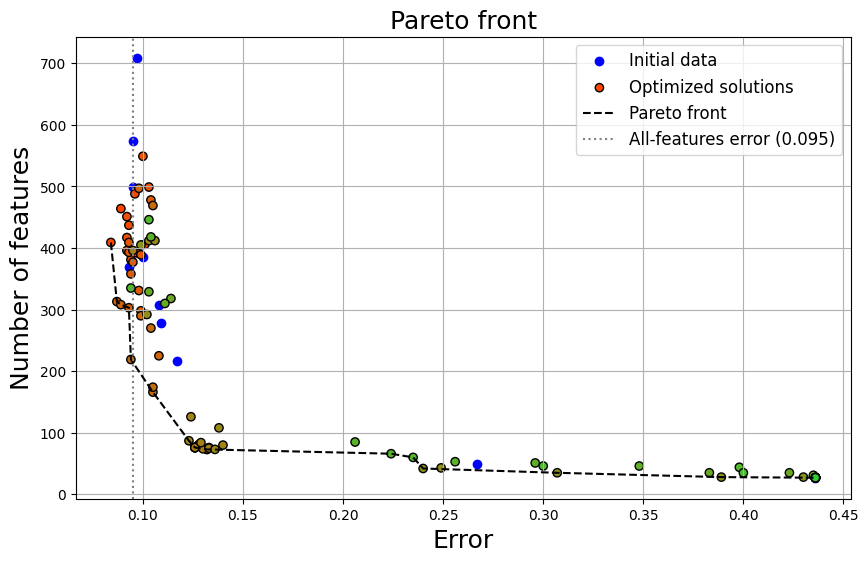

As the search progresses (red to green), notice how the solutions move toward the bottom right, the region with fewer features. This is the result of exploring a wide range of solutions by shifting the weight over the course of the search.

The black dashed line traces out the trade-off between the number of features and the error rate. While reducing the number of features (moving down in the graph) tends to increase the error rate (moving right in the graph), the plot shows that some solutions cut the number of features dramatically while keeping the error rate close to the baseline.

<a id="sec-3_3"></a>

### 3.3\. Summary

In this sample, we used `MultiOptimizer` to handle two competing objectives — error rate and number of features — at once, and by varying the surrogate model's weight over the course of the optimization cycle, we obtained a diverse set of solutions from a single optimization run.

The resulting Pareto front shows that some solutions cut the number of features substantially without significantly worsening the error rate compared with the all-784-feature baseline. In practice, you would pick a solution from this Pareto front based on requirements such as the maximum acceptable error rate or a target number of features.